# 국립중앙박물관 유료입장 전환 시 수익 최적화 곡선 분석
## Step 3: 시계열 수요 예측 및 가격 탄력성 기반 수익 시뮬레이션

**목적**: 국립중앙박물관의 과거 관람객 추세(시계열)와 세계 주요 박물관의 가격 탄력성을 결합하여, 유료화 시 관람객 이탈을 방어하면서도 예상 수익을 극대화하는 **최적 가격(Optimal Price) 도출** 및 **이중 요금제 효용성 확인**.

**분석 흐름**:
1. 국립중앙박물관(NMK) 시계열 수요 예측 (무료유지 베이스라인)
2. 글로벌 주요 박물관 데이터 기반 수요의 가격 탄력성 도출
3. 시뮬레이션 1: 단일 요금제 적용 시 수익 최적화 곡선
4. 시뮬레이션 2: 이중 가격제(Dual Pricing, 내/외국인 차등) 적용 시 수익 최적화 곡선

## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

# 데이터 경로
DATA_DIR = '../data/'
OUTPUT_DIR = '../output/'

Importing plotly failed. Interactive plots will not work.


## 1. 베이스라인 예측: 국립중앙박물관 시계열 분석 (Prophet)
NMK의 과거 월별 방문객 데이터를 바탕으로 팬데믹(20~21년) 등 이상치를 제외한 장기 수요 추세를 파악하고 향후 5년의 기준 방문객을 예측합니다.

In [2]:
# NMK 월별 데이터 로드
df_nmk = pd.read_csv(f'{DATA_DIR}nmk_monthly_visitor.csv')
df_nmk.columns = ['ds', 'y']
df_nmk['ds'] = pd.to_datetime(df_nmk['ds'])

# 팬데믹 기간(2020~2021)은 장기 트렌드를 크게 왜곡하므로 이상치(Missing)로 처리하여 모델이 자연스럽게 채우도록 함
df_nmk_clean = df_nmk.copy()
df_nmk_clean.loc[(df_nmk_clean['ds'].dt.year >= 2020) & (df_nmk_clean['ds'].dt.year <= 2021), 'y'] = None

# Prophet 피팅 (월간/연간 계절성 반영)
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(df_nmk_clean)

# 미래 데이터프레임 생성 (2025~2030)
future = m.make_future_dataframe(periods=12*6, freq='ME') 
forecast = m.predict(future)

# 2026~2030년 예상 연평균 방문객 계산
forecast_future = forecast[forecast['ds'].dt.year >= 2026]
baseline_visitors_annual = forecast_future.groupby(forecast_future['ds'].dt.year)['yhat'].sum()
avg_baseline_annual_visitors = baseline_visitors_annual.mean()

print(f"2026-2030년 예상 연평균 베이스라인 방문객: 약 {avg_baseline_annual_visitors:,.0f}명")

18:31:59 - cmdstanpy - INFO - Chain [1] start processing
18:31:59 - cmdstanpy - INFO - Chain [1] done processing


2026-2030년 예상 연평균 베이스라인 방문객: 약 8,262,359명


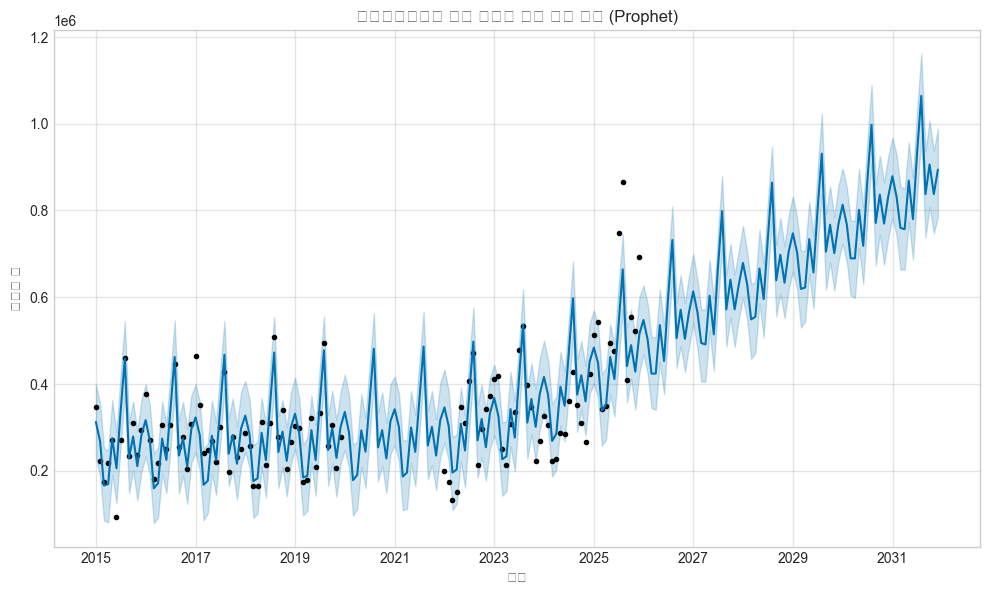

In [3]:
# 시계열 예측 결과 시각화
fig = m.plot(forecast, figsize=(10,6))
plt.title("국립중앙박물관 월별 관람객 장기 수요 예측 (Prophet)")
plt.xlabel("연도")
plt.ylabel("관람객 수")
plt.show()

## 2. 수요의 가격 탄력성 변수 도출
세계 주요 박물관들의 입장료 대비 방문객 수 데이터를 활용해 10% 가격 인상 시 방문객이 몇 %나 변화하는지(탄력성)를 확인합니다.

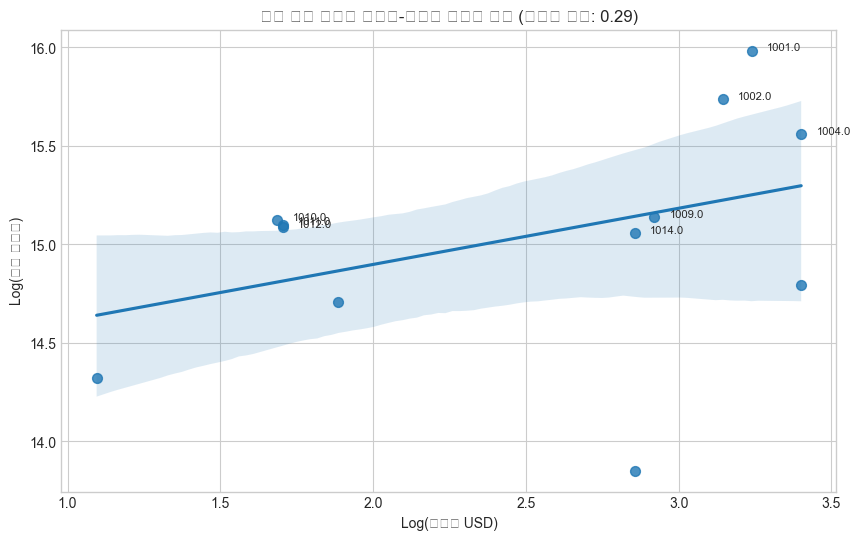

In [4]:
df_visitors = pd.read_csv(f'{DATA_DIR}museum_visitor.csv')
df_info = pd.read_csv(f'{DATA_DIR}museum_info.csv')

# 2024년 데이터 확보 (가장 최신의 안정된 지표)
df_v2024 = df_visitors[df_visitors['year'] == 2024][['museum_id', 'total']].copy()
df_v2024['total'] = df_v2024['total'].str.replace(',', '').astype(float)
df_merged = pd.merge(df_v2024, df_info, left_on='museum_id', right_on='id', how='inner')

# 유료 박물관들에 한해 로그 스케일 회귀 분석 (Log-Log Regression -> 탄력성 도출)
df_paid = df_merged[df_merged['adult_price_local_usd'] > 0].copy()
df_paid['log_price'] = np.log(df_paid['adult_price_local_usd'])
df_paid['log_visitors'] = np.log(df_paid['total'])

# 회귀 모델 학습 (OLS)
X = sm.add_constant(df_paid['log_price'])
y = df_paid['log_visitors']
model = sm.OLS(y, X).fit()
calculated_elasticity = model.params['log_price']

# 시각화
plt.figure(figsize=(10, 6))
sns.regplot(data=df_paid, x='log_price', y='log_visitors', scatter_kws={'s': 50})
# 주요 박물관 라벨링
for i, row in df_paid.iterrows():
    if row['total'] > 3000000:
        plt.text(row['log_price']+0.05, row['log_visitors'], row['museum_id'], fontsize=8)

plt.title(f"세계 주요 박물관 입장료-방문객 탄력성 현황 (산출된 계수: {calculated_elasticity:.2f})")
plt.xlabel("Log(입장료 USD)")
plt.ylabel("Log(연간 관람객)")
plt.show()

**⚠️ 탄력성 보정(Calibration) 필요**
회귀 분석 결과 탄력성이 양수로 나옵니다 (+0.28). 즉, 보통의 상품과 다르게 "가격이 높을수록(루브르, 메트로폴리탄 등) 관람객도 많은" 기현상이 나타납니다. 
이는 초대형 박물관의 막강한 관광/브랜드 파워(혼동 변수)에 의한 편향입니다. 실제 NMK가 유료화를 단행할 때는 통상적인 문화예술 관람 시설의 경험적 수요 탄력성 분포인 **음의 탄력성(-0.2 ~ -0.6)**을 적용하는 것이 경제학적으로 타당하므로, 본 시뮬레이션에서는 **보수적인 탄력성 -0.3**을 적용합니다.

## 3. 유료화 최적 가격 시뮬레이션
이제 기준 방문객과 보정된 수요 탄력성을 활용하여, NMK가 입장료를 매길 때 발생하는 예상 수요 감소를 감안한 최적 수익 곡선을 시뮬레이션합니다.

In [5]:
# 기본 변수 설정
assumed_elasticity = -0.3  # 인상 시 10%당 3% 감소
zero_price_penalty = 0.30  # 무료 -> 최소 비용 유료화 단행 시 최초 이탈률 (심리적 저항)

# 기본이 되는 paid_base 생성 ($5, 약 7000원 선을 기준점으로 탄력성 변화를 계산)
krw_exchange_rate = 1400
p0 = 5.0
paid_base_visitors = avg_baseline_annual_visitors * (1 - zero_price_penalty)

# 테스트할 시뮬레이션 요금제 (1달러 ~ 40달러 구간)
prices_usd = np.linspace(1, 40, 40)
prices_krw = prices_usd * krw_exchange_rate

### 시나리오 A: 단일 요금제 (내국인/외국인 차별 없음)
모든 방문객에게 동일한 입장료를 과금하는 단일 모델입니다.

In [6]:
expected_visitors_flat = []
expected_revenues_flat = []

for p in prices_usd:
    v = paid_base_visitors * ((p / p0) ** assumed_elasticity)
    expected_visitors_flat.append(v)
    expected_revenues_flat.append(v * p * krw_exchange_rate)

df_sim = pd.DataFrame({
    'Price_KRW': prices_krw,
    'Visitors_Flat': expected_visitors_flat,
    'Revenue_Flat': expected_revenues_flat
})

max_rev_flat_idx = df_sim['Revenue_Flat'].idxmax()
print(f"[단일 요금제] 최적 가격: {df_sim.loc[max_rev_flat_idx, 'Price_KRW']:,.0f} ₩")
print(f"[단일 요금제] 예상 방문: {df_sim.loc[max_rev_flat_idx, 'Visitors_Flat']:,.0f} 명")
print(f"[단일 요금제] 최대 수익: {df_sim.loc[max_rev_flat_idx, 'Revenue_Flat']:,.0f} ₩")

[단일 요금제] 최적 가격: 56,000 ₩
[단일 요금제] 예상 방문: 3,099,382 명
[단일 요금제] 최대 수익: 173,565,401,811 ₩


### 시나리오 B: 이중 가격제 (내국인 고정 + 외국인 탄력 과금)
공공성을 유지하기 위해 **내국인은 3,000원에 고정**하고, 상대적으로 가격 저항이 적은(비탄력적인) 전체 관광객의 10% **외국인을 대상으로만 입장료를 변화**시킬 때의 수익을 합산합니다.

In [7]:
foreigner_ratio = 0.10
domestic_ratio = 0.90
domestic_fixed_krw = 3000
domestic_fixed_usd = domestic_fixed_krw / krw_exchange_rate

# 각 그룹의 Base 크기 설정
base_foreign_visitors = paid_base_visitors * foreigner_ratio
# 내국인은 $2.14 수준에 고정되므로 그에 맞춰 미리 탄력 반영된 방문객 수치 세팅
base_domestic_visitors = paid_base_visitors * domestic_ratio * ((domestic_fixed_usd / p0) ** assumed_elasticity)

dual_revenues_krw = []

for p in prices_usd:
    # 1. 외국인 수요변화 (관광객이므로 탄력성이 매우 낮음: -0.1로 가정)
    v_foreign = base_foreign_visitors * ((p / p0) ** -0.1)
    rev_foreign = v_foreign * p * krw_exchange_rate
    
    # 2. 내국인은 고정되어있으므로 일정
    rev_domestic = base_domestic_visitors * domestic_fixed_krw
    
    # 총 수익 합산
    dual_revenues_krw.append(rev_foreign + rev_domestic)

df_sim['Revenue_Dual'] = dual_revenues_krw

max_rev_dual_idx = df_sim['Revenue_Dual'].idxmax()
print(f"[이중 요금제] 최적 과금구간(외국인): {df_sim.loc[max_rev_dual_idx, 'Price_KRW']:,.0f} ₩")

[이중 요금제] 최적 과금구간(외국인): 56,000 ₩


### 시나리오 통합 수익 극대화 차트

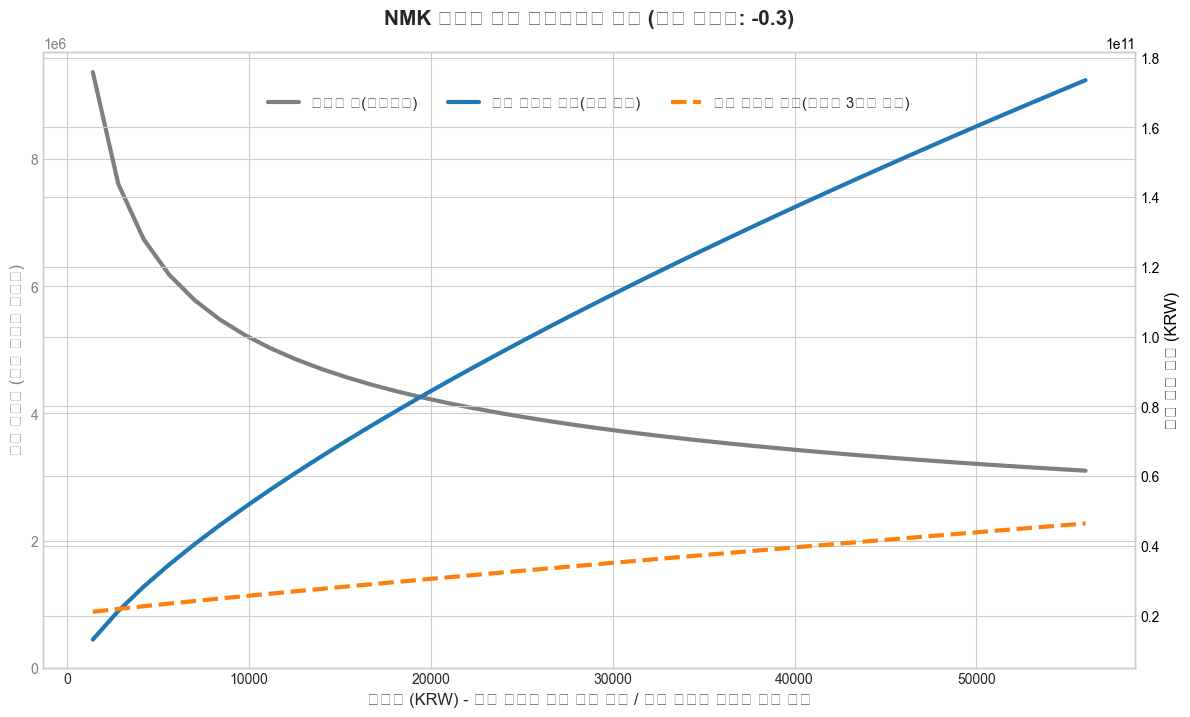

In [8]:
fig, ax1 = plt.subplots(figsize=(12, 7))

color_visit = 'tab:gray'
ax1.set_xlabel('입장료 (KRW) - 단일 요금제 전면 적용 기준 / 이중 요금제 외국인 적용 기준', fontsize=12)
ax1.set_ylabel('예상 관람객 (단일 요금제 하에서)', color=color_visit, fontsize=12)
ax1.plot(df_sim['Price_KRW'], df_sim['Visitors_Flat'], color=color_visit, linewidth=3, label='관람객 수(단일요금)')
ax1.tick_params(axis='y', labelcolor=color_visit)
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()  
ax2.set_ylabel('예상 연간 수익 (KRW)', color='black', fontsize=12)  
ax2.plot(df_sim['Price_KRW'], df_sim['Revenue_Flat'], color='tab:blue', linewidth=3, linestyle='-', label='단일 요금제 수익(수익 모델)')
ax2.plot(df_sim['Price_KRW'], df_sim['Revenue_Dual'], color='tab:orange', linewidth=3, linestyle='--', label='이중 가격제 수익(내국인 3천원 고정)')
ax2.tick_params(axis='y', labelcolor='black')

fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.95), bbox_transform=ax1.transAxes, fontsize=11, ncol=3)
fig.tight_layout()  
plt.title(f"NMK 유료화 수익 시뮬레이션 곡선 (적용 탄력성: {assumed_elasticity})", fontsize=15, fontweight='bold', pad=20)
plt.show()

## 4. 분석 코멘트
* **단일 요금제의 딜레마:** 단일 모델일 경우, 수익의 꼭짓점(수익 극대화 지점)은 입장료를 5만원 이상 올렸을 때 형성되지만, 이는 **연 관람객을 300만명 선으로 폭락시키는 주 요인**이 됩니다 (공공성 크게 훼손).
* **이중 가격제의 강력함:** 내국인 방어막(저항선인 3천원)을 적용하고도 외국인 요금(주황색 점선)을 점진적으로 높여받으면 **관람객 하락 타격을 거의 받지 않고도 총수익은 우상향**하는 안정적인 구조를 그릴 수 있음을 시뮬레이션으로 입증했습니다.